In [ ]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

$$H(s) = \frac{w_{c}}{s + w_{c}}$$

<br>

$$ f_{c} = 100 \hspace{2cm} w_{c} = 2\pi.f_{c}$$


In [ ]:
fc = 100
wc = 2*np.pi*fc

## **1. Creación del sistem**

In [ ]:
num = [wc]
den=[1, wc]

hs = signal.lti(num,den)
hs

TransferFunctionContinuous(
array([628.31853072]),
array([  1.        , 628.31853072]),
dt: None
)

## **2. Diagrama de bode**

In [ ]:
w, mag, phase = hs.bode() # ya te devuelve la magnitud en rad/s y fase en grados

w_f = w/(2*np.pi)

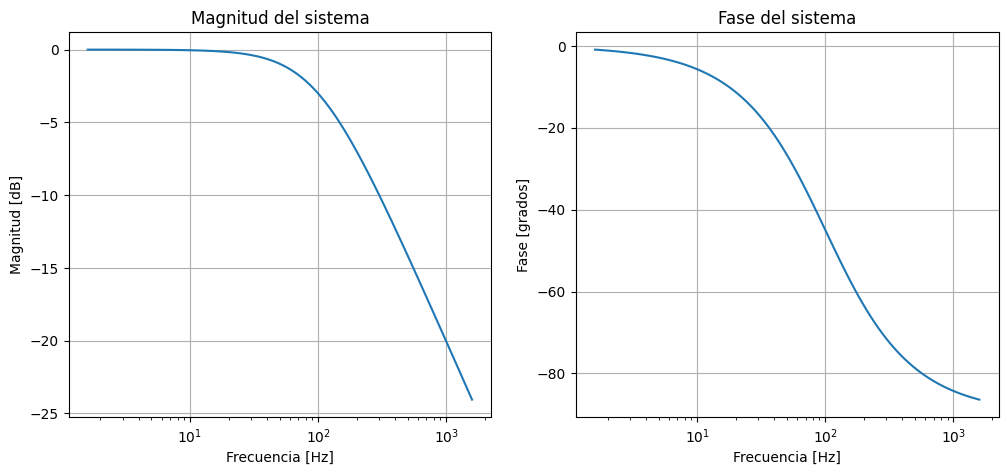

In [ ]:
# @title Gráfica de magnitud y fase
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Magnitud del sistema")
plt.semilogx(w_f, mag)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()

plt.subplot(1,2,2)
plt.title("Fase del sistema")
plt.semilogx(w_f, phase)  # Bode phase plot
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.show()

## **3. Estabilidad del sistema**

In [ ]:
zpk = hs.to_zpk()

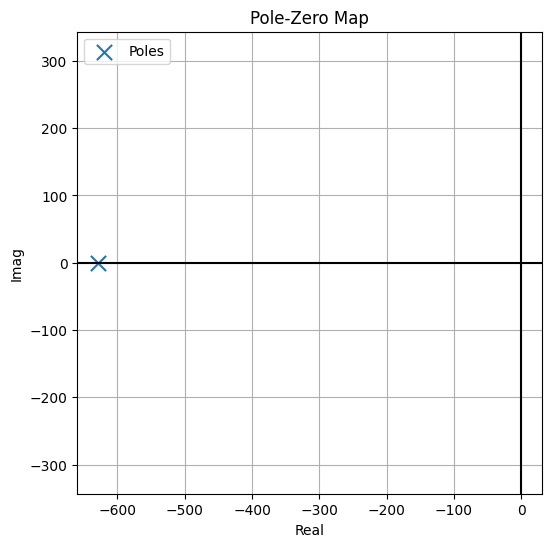

In [ ]:
# @title Diagrama de estabilidad de polos y ceros
# extraer
z = zpk.zeros
p = zpk.poles

# plot
plt.figure(figsize=(6,6))

# zeros
if len(z) > 0:
    plt.scatter(np.real(z), np.imag(z),
                marker='o', s=120, label='Zeros')

# poles
plt.scatter(np.real(p), np.imag(p),
            marker='x', s=120, label='Poles')

# ejes
plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.xlabel("Real")
plt.ylabel("Imag")

plt.title("Pole-Zero Map")

plt.grid()
plt.legend()

plt.axis('equal')

plt.show()

## **4. Respuesta al impulse**

In [ ]:
t, y = signal.impulse(hs)

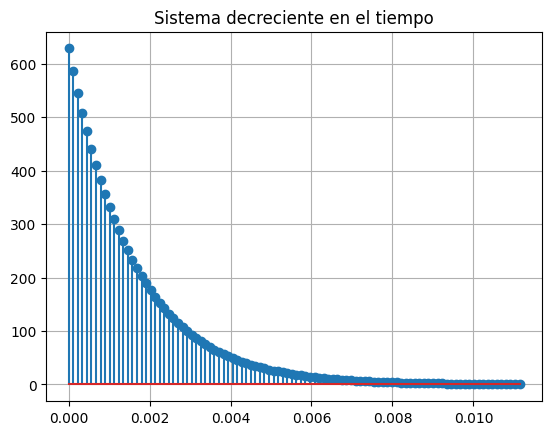

In [ ]:
# @title Diagrama de respuesta al impulse
plt.title("Sistema decreciente en el tiempo")
plt.stem(t, y)
plt.grid()
plt.show()